In [1]:
!pip install adversarial-robustness-toolbox
!pip install torch torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from art.estimators.classification import PyTorchClassifier
from art.attacks.inference.model_inversion import MIFace

In [6]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [9]:
train_dataset = datasets.CIFAR10(
    root="./",
    train=True,
    download=False,
    transform=transform
)
test_dataset = datasets.CIFAR10(
    root="./",
    train=False,
    download=False,
    transform=transform
)

## ##to check CIFAR working or not

In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

Text(0.5, 0.98, 'Sample CIFAR10 Images')

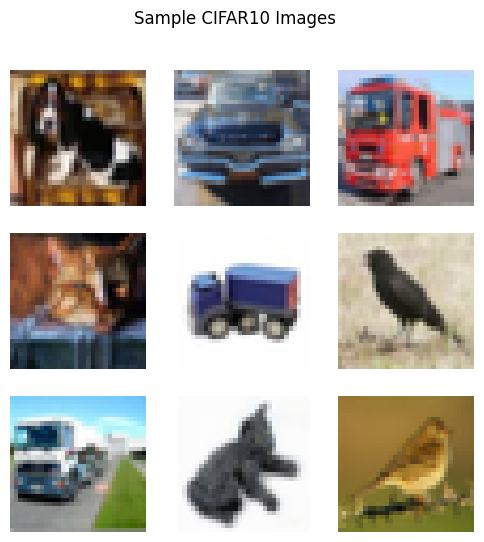

In [ ]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("Sample CIFAR10 Images")

Define CNN Model 

In [15]:
import torch.nn as nn
class CIFARModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64*8*8,256),
            nn.ReLU(),
            nn.Linear(256,10)
        )
    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)
        return x

In [16]:
model = CIFARModel()
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Train Model

In [17]:
epochs = 5
for epoch in range(epochs):
    running_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print("Epoch:", epoch, "Loss:", running_loss)

Epoch: 0 Loss: 619.2640669345856
Epoch: 1 Loss: 474.6645917892456
Epoch: 2 Loss: 416.7706809043884
Epoch: 3 Loss: 374.8643637895584
Epoch: 4 Loss: 339.3703519105911


Model Accuracy

In [18]:
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = correct/total
print("Model Accuracy:", accuracy)

Model Accuracy: 0.6715


ART Classifier

In [19]:
from art.estimators.classification import PyTorchClassifier

classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3,32,32),
    nb_classes=10
)

Model Inversion Attack

In [20]:
from art.attacks.inference.model_inversion import MIFace
attack = MIFace(classifier)
sample_images, sample_labels = next(iter(train_loader))
reconstructed = attack.infer(
    x=sample_images.numpy(),
    y=sample_labels.numpy()
)

Model inversion: 100%|██████████| 128/128 [27:59<00:00, 13.12s/it]


Reconstructed Image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-323.68585..213.78566].


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

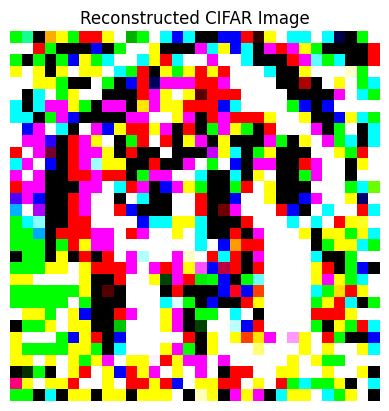

In [21]:
img = reconstructed[0].transpose(1,2,0)
plt.imshow(img)
plt.title("Reconstructed CIFAR Image")
plt.axis("off")